### Assignment: Logistic Regression and Multiclass Logistic Regression <font color='red'>**[70 points]**</font>

## Objective
The goal of this assignment is to understand the implementation of logistic regression and its extension to multiclass classification. You will start by implementing binary logistic regression using maximum likelihood estimation, then extend it to multiclass logistic regression using softmax. Additionally, they will explore the impact of L1 and L2 regularization.

## 1. Choice of Dataset <font color='red'>**[5+5 points]**</font>
- You can choose any appropriate dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/datasets) for this assignment.
- The dataset should be suitable for:
  - (i) **Binary classification** (e.g., Spam detection, Disease prediction).
  - (ii) **Multiclass classification** (e.g., Iris, Digit recognition, Species classification).
- You need to properly refer/ add link to all the datasets used in the experiments in separate in the **IPYNB code**. <font color='red'>**Zero marking otherwise!**</font>

## Instructions
### 2. Implement Logistic Regression <font color='red'>**[10 points]**</font>
- Implement **Binary Logistic Regression** using **linear-logistic function**.
- Train the model on a **dataset of your choice from the UCI repository**.
- Select **a random subset of 5000 entries** from the UCI-dataset of your choice to create a smaller dataset.
- Split the dataset into **train (60%) and test sets (40%)**
- Report **Squared Loss** and **Absolute Loss** as the evaluation metric.


### 3. Dataset Scaling and Reporting Observations
(A) **Vary training set size**: <font color='red'>**[10 points]**</font>
- Set training set sizes to **20%, 40%, 60%, and 80%** while using the remaining data as the test set.
-  Include L1 (Lasso) and L2 (Ridge) regularization using **k-fold cross-validation**
- Plot the **test loss with increasing training set size** with (L1, L2) and without any regularization.
- **Report observations and inferences** on model performance.

(B) **Increase dataset size**: <font color='red'>**[10 points]**</font>
- Expand the dataset to **10K and 20K samples** and perform the same task as in (A).
- **Report observations and inferences** on how dataset size affects generalization.

### 4. Extend to Multiclass Logistic Regression <font color='red'>**[20 points]**</font>
- Now consider the dataset you chose for multiclass classification in **(#1)** above.
- Implement **Multiclass Logistic Regression** using the **linear-multiclass logistic function**.
- Repeat the tasks given in **(#3)** on the **selected dataset**.

### 5. Additional Questions <font color='red'>**[5+5 points]**</font>
- **How do you select the appropriate value of k in k-fold cross-validation?** Discuss the trade-off between bias and variance when choosing k.
- **How did you handle the missing / nan entries in the dataset?** Why did you use that method?

## Hints
- Use `numpy` for efficient matrix operations.
- Use `matplotlib` to visualize decision boundaries.
- Utilize `scikit-learn` functions for dataset preprocessing.
- Ensure numerical stability by implementing proper initialization and gradient clipping where necessary.


### 1. Choice of Dataset
Slate, D. (1991). Letter Recognition [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5ZP40.

This is a dataset of character image features with the goal to identify the letter shown.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import KFold
  
# fetch dataset 
letter_recognition = fetch_ucirepo(id=59) 
  
# data (as pandas dataframes) 
X = letter_recognition.data.features 
y = letter_recognition.data.targets 
  
# metadata 
print(letter_recognition.metadata) 
  
# variable information 
print(letter_recognition.variables) 


{'uci_id': 59, 'name': 'Letter Recognition', 'repository_url': 'https://archive.ics.uci.edu/dataset/59/letter+recognition', 'data_url': 'https://archive.ics.uci.edu/static/public/59/data.csv', 'abstract': 'Database of character image features; try to identify the letter', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 20000, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['lettr'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1991, 'last_updated': 'Thu Sep 28 2023', 'dataset_doi': '10.24432/C5ZP40', 'creators': ['David Slate'], 'intro_paper': None, 'additional_info': {'summary': 'The objective is to identify each of a large number of black-and-white rectangular pixel displays as one of the 26 capital letters in the English alphabet.  The character images were based on 20 different fonts and each letter within these 20 fonts wa

### 2. Implement Logistic Regression

Binary target: The letter A versus all other letters, i.e. 1 if letter == 'A', else 0

In [2]:
X_all = X.to_numpy(dtype=np.float64)
y_labels = y.iloc[:, 0].astype(str).to_numpy()
y_all = (y_labels == "A").astype(np.float64)

rng = np.random.default_rng(12)
idx = rng.choice(X_all.shape[0], size=5000, replace=False)

X_sub = X_all[idx]
y_sub = y_all[idx]

X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=0.4,
    random_state=12,
    stratify=y_sub
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b  = np.c_[np.ones((X_test.shape[0], 1)),  X_test]

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def fit_logreg_gd(X, y, lr=0.1, epochs=2000, reg_type=None, lam=0.0):
    n, d = X.shape
    w = np.zeros(d)

    for _ in range(epochs):
        p = sigmoid(X @ w)
        grad = (X.T @ (p - y)) / n

        if reg_type == "l2":
            grad[1:] += lam * w[1:]

        elif reg_type == "l1":
            grad[1:] += lam * np.sign(w[1:])

        w -= lr * grad

    return w

w = fit_logreg_gd(X_train_b, y_train, lr=0.1, epochs=2000)

p_test = sigmoid(X_test_b @ w)

squared_loss = np.mean((p_test - y_test) ** 2)
absolute_loss = np.mean(np.abs(p_test - y_test))

print("Test Squared Loss:", squared_loss)
print("Test Absolute Loss:", absolute_loss)

y_pred = (p_test >= 0.5).astype(int)
accuracy = np.mean(y_pred == y_test)
print("Test Accuracy:", accuracy)

Test Squared Loss: 0.008399957648939794
Test Absolute Loss: 0.03091269631494965
Test Accuracy: 0.9915


### 3. Dataset Scaling and Reporting Observations


Dataset size N=5000
Positive rate overall: 0.03945
Positive rate in sampled subset: 0.0394

Dataset size N=10000
Positive rate overall: 0.03945
Positive rate in sampled subset: 0.0377

Dataset size N=20000
Positive rate overall: 0.03945
Positive rate in sampled subset: 0.03945


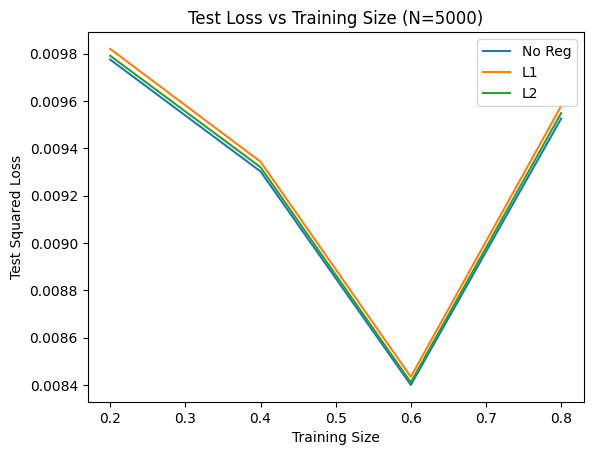

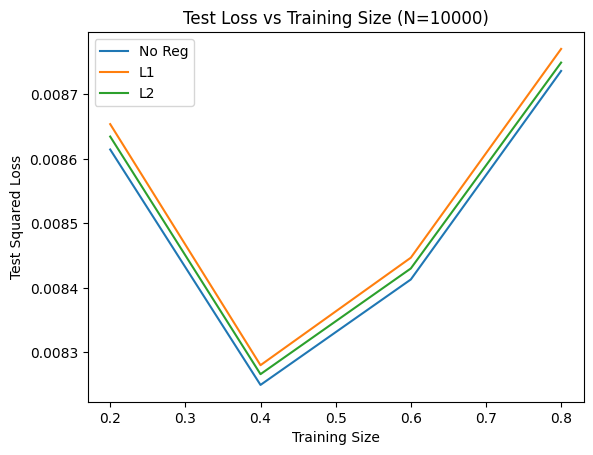

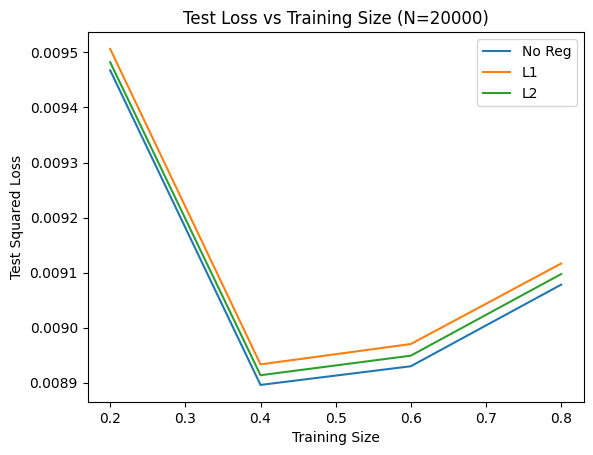

In [3]:
def cross_validate(X, y, reg_type, lambdas, k=5, lr=0.1, epochs_cv=800):
    kf = KFold(n_splits=k, shuffle=True, random_state=12)
    best_lambda, best_loss = None, float("inf")

    for lam in lambdas:
        fold_losses = []
        for tr_idx, val_idx in kf.split(X):
            X_tr, X_val = X[tr_idx], X[val_idx]
            y_tr, y_val = y[tr_idx], y[val_idx]

            w = fit_logreg_gd(X_tr, y_tr, lr=lr, epochs=epochs_cv, reg_type=reg_type, lam=lam)
            p_val = sigmoid(X_val @ w)
            fold_losses.append(np.mean((p_val - y_val) ** 2))

        avg_loss = np.mean(fold_losses)
        if avg_loss < best_loss:
            best_loss, best_lambda = avg_loss, lam

    return best_lambda

def run_experiment_for_N(X_all, y_all, N, train_sizes, lambdas, k=5, seed=12, lr=0.1, epochs_final=2000, epochs_cv=800):
    rng = np.random.default_rng(seed)
    idx = rng.choice(X_all.shape[0], size=N, replace=False)
    X_sub = X_all[idx]
    y_sub = y_all[idx]

    print(f"\nDataset size N={N}")
    print("Positive rate overall:", y_all.mean())
    print("Positive rate in sampled subset:", y_sub.mean())

    results = {
        "N": N,
        "train_sizes": train_sizes,
        "no_reg": [],
        "l1": [],
        "l2": [],
        "best_l1": [],
        "best_l2": []
    }

    for size in train_sizes:
        X_train, X_test, y_train, y_test = train_test_split(
            X_sub, y_sub, train_size=size, random_state=12, stratify=y_sub
        )

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
        X_test  = np.c_[np.ones((X_test.shape[0], 1)),  X_test]

        # No regularization
        w = fit_logreg_gd(X_train, y_train, lr=lr, epochs=epochs_final)
        p = sigmoid(X_test @ w)
        results["no_reg"].append(np.mean((p - y_test) ** 2))

        # L1 regularization
        best_l1 = cross_validate(X_train, y_train, "l1", lambdas, k=k, lr=lr, epochs_cv=epochs_cv)
        w = fit_logreg_gd(X_train, y_train, lr=lr, epochs=epochs_final, reg_type="l1", lam=best_l1)
        p = sigmoid(X_test @ w)
        results["l1"].append(np.mean((p - y_test) ** 2))
        results["best_l1"].append(best_l1)
        
        # L2 regularization
        best_l2 = cross_validate(X_train, y_train, "l2", lambdas, k=k, lr=lr, epochs_cv=epochs_cv)
        w = fit_logreg_gd(X_train, y_train, lr=lr, epochs=epochs_final, reg_type="l2", lam=best_l2)
        p = sigmoid(X_test @ w)
        results["l2"].append(np.mean((p - y_test) ** 2))
        results["best_l2"].append(best_l2)

    return results


train_sizes = [0.2, 0.4, 0.6, 0.8]
lambdas = [1e-4, 1e-3, 1e-2, 1e-1]

all_results = []
for N in [5000, 10000, 20000]:
    res = run_experiment_for_N(X_all, y_all, N, train_sizes, lambdas, k=5, seed=12, lr=0.1, epochs_final=2000, epochs_cv=800)
    all_results.append(res)

for res in all_results:
    plt.figure()
    plt.plot(res["train_sizes"], res["no_reg"], label="No Reg")
    plt.plot(res["train_sizes"], res["l1"], label="L1")
    plt.plot(res["train_sizes"], res["l2"], label="L2")
    plt.xlabel("Training Size")
    plt.ylabel("Test Squared Loss")
    plt.title(f"Test Loss vs Training Size (N={res['N']})")
    plt.legend()
    plt.show()

#### Observations and Inferences for 3(A): Varying Training Set Size (20%, 40%, 60%, 80%)



- Across all settings, **test squared loss is low** (roughly in the $10^{-3}$ to $10^{-2}$ range), indicating the binary task (A vs not-A) is learnable with this feature set.

- In all three dataset sizes ($N=5000, 10000, 20000$), performance improves from small training fractions and reaches its best region around **40%–60% train size**.

- At 80% train size, test loss often increases slightly. Since test size becomes smaller, this estimate has higher variance; the slight increase is likely due to split variability and class imbalance effects rather than model failure.

- **L1, L2, and no-regularization curves are very close**, meaning regularization has limited marginal impact in this setup.

- When there is a difference, **L2 is usually slightly better than L1**, while no regularization is often competitive or best.



#### Observations and Inferences for 3(B): Increasing Dataset Size to 10K and 20K



- Moving from smaller to larger total datasets keeps the same general trend (best performance around mid-range train fractions), but the curves become more stable.

- With larger datasets, the model maintains **consistently low test loss**, showing improved generalization from having more diverse training examples.

- Regularization still provides only a small change in loss; this suggests the base logistic model is already well-conditioned after standardization.

- Overall, increasing dataset size helps generalization reliability more than changing between L1/L2 in this specific binary classification task.

- Practical takeaway: for this dataset, prioritize more data and stable splits; use L2 as a safe default if regularization is required.
